In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as scp
from scipy import optimize
from scipy.optimize import curve_fit
%matplotlib inline

### Primeiros testes Gabriel

In [46]:
dados = {
    "Evento": [
        "1500 m", "1500 m (indoor)", "One mile", "3000 m", "3000 m (indoor)", 
        "Two miles", "Two miles (indoor)", "5000 m", "5000 m (indoor)", 
        "10 000 m", "5 km", "10 km", "Half marathon", "30 km", "Marathon"
    ],
    # metros
    "Distancia_m": [
        1500.0, 1500.0, 1609.34, 3000.0, 3000.0, 
        3218.68, 3218.68, 5000.0, 5000.0, 
        10000.0, 5000.0, 10000.0, 21097.5, 30000.0, 42195.0
    ],
    # segundo
    "Tempo_s": [
        213.0, 216.0, 230.0, 448.0, 449.0, 
        488.0, 487.0, 767.0, 776.0, 
        1609.0, 791.0, 1691.0, 3565.0, 5233.0, 7299.0
    ],
    # metros/segundo
    "Velocidade_ms": [
        7.04, 6.94, 6.98, 6.70, 6.68, 
        6.60, 6.60, 6.52, 6.45, 
        6.21, 6.32, 5.91, 5.92, 5.73, 5.78
    ]
}
df = pd.DataFrame(dados)

df.rename(columns={"Tempo_s":"Tempo_h", "Velocidade_ms":"Velocidade_kmh","Distancia_m":"Distancia_km"},inplace=True)

df['Tempo_h'] = df['Tempo_h'] / 3600 # s → h
df['Distancia_km'] = df['Distancia_km'] / 1000 # m → km
df['Velocidade_kmh'] = df['Velocidade_kmh'] * 3.6 # m/s → km/h

tempos = df['Tempo_h'].values
velocidades = df['Velocidade_kmh'].values
distancias = df['Distancia_km'].values

In [47]:
def modelo_sigmoide(T, A, k, t0, V_base):
    return V_base + A / (1.0 + np.exp(k * (T - t0)))

def modelo_potencia(T, S, E):
    return S * T**(E - 1.0)

def modelo_hyper(T, a, alpha,gamma):
    # Erro
    # return (a * T**alpha) / (T**alpha + gamma**alpha) + a 
    return (a * gamma**alpha) / (T**alpha + gamma**alpha)

In [48]:
# Chutes iniciais
p0_sig = [np.max(velocidades)-np.min(velocidades), 5.0, 0.5, np.min(velocidades)*0.8] # [ Diferença máxima entre as velocidades | ]
p0_pow = [27, 0.9]
p0_hyper = [20,-2,50]

# Executando os fittings
popt_sig, _ = optimize.curve_fit(modelo_sigmoide, tempos, velocidades, p0=p0_sig, maxfev=10000,bounds=([0,-50,-1000,0],[100,100,1000,np.max(velocidades)*1.05]))
popt_pow, _ = optimize.curve_fit(modelo_potencia, tempos, velocidades, p0=p0_pow, maxfev=10000)
popt_hyper, _ = optimize.curve_fit(modelo_hyper, tempos, velocidades, p0=p0_hyper, maxfev=10000,bounds=([0,-10,0.001],[np.max(velocidades)*1.05,10,10000]))

# Cálculo dos resíduos e normas
erro_sig = velocidades - modelo_sigmoide(tempos, *popt_sig)
erro_pow = velocidades - modelo_potencia(tempos, *popt_pow)
erro_hyper = velocidades - modelo_hyper(tempos, *popt_hyper)

norma_sig = np.linalg.norm(erro_sig)
norma_pow = np.linalg.norm(erro_pow)
norma_hyper = np.linalg.norm(erro_hyper)

In [49]:
print("--- Parâmetros Fitados ---")

# Sigmóide: [Amplitude (A), k, t0, V_base]
print(f"Sigmóide:")
print(f"  Amplitude de queda: {popt_sig[0]:.3f} km/h")
print(f"  Taxa de decaimento (k): {popt_sig[1]:.5f}")
print(f"  Ponto de inflexão (t0): {popt_sig[2]:.1f} s")
print(f"  Velocidade Base (Assíntota): {popt_sig[3]:.3f} km/h\n")

# Lei de Potência (Riegel): [S, E]
print(f"Lei de Potência:")
print(f"  Velocidade Limite (S): {popt_pow[0]:.3f} km/h")
print(f"  Fator de Endurance (E): {popt_pow[1]:.4f}\n")

# Hyper: [a, alpha, gamma]
print(f"Hyper:")
print(f"  Velocidade Máxima (a): {popt_hyper[0]:.3f} km/h")
print(f"  Decaimento (alpha): {popt_hyper[1]:.4f}")
print(f"  Fator de escala (gamma): {popt_hyper[2]:.1f}")

--- Parâmetros Fitados ---
Sigmóide:
  Amplitude de queda: 100.000 km/h
  Taxa de decaimento (k): 4.15401
  Ponto de inflexão (t0): -0.7 s
  Velocidade Base (Assíntota): 20.893 km/h

Lei de Potência:
  Velocidade Limite (S): 21.171 km/h
  Fator de Endurance (E): 0.9401

Hyper:
  Velocidade Máxima (a): 26.611 km/h
  Decaimento (alpha): 0.3893
  Fator de escala (gamma): 35.7


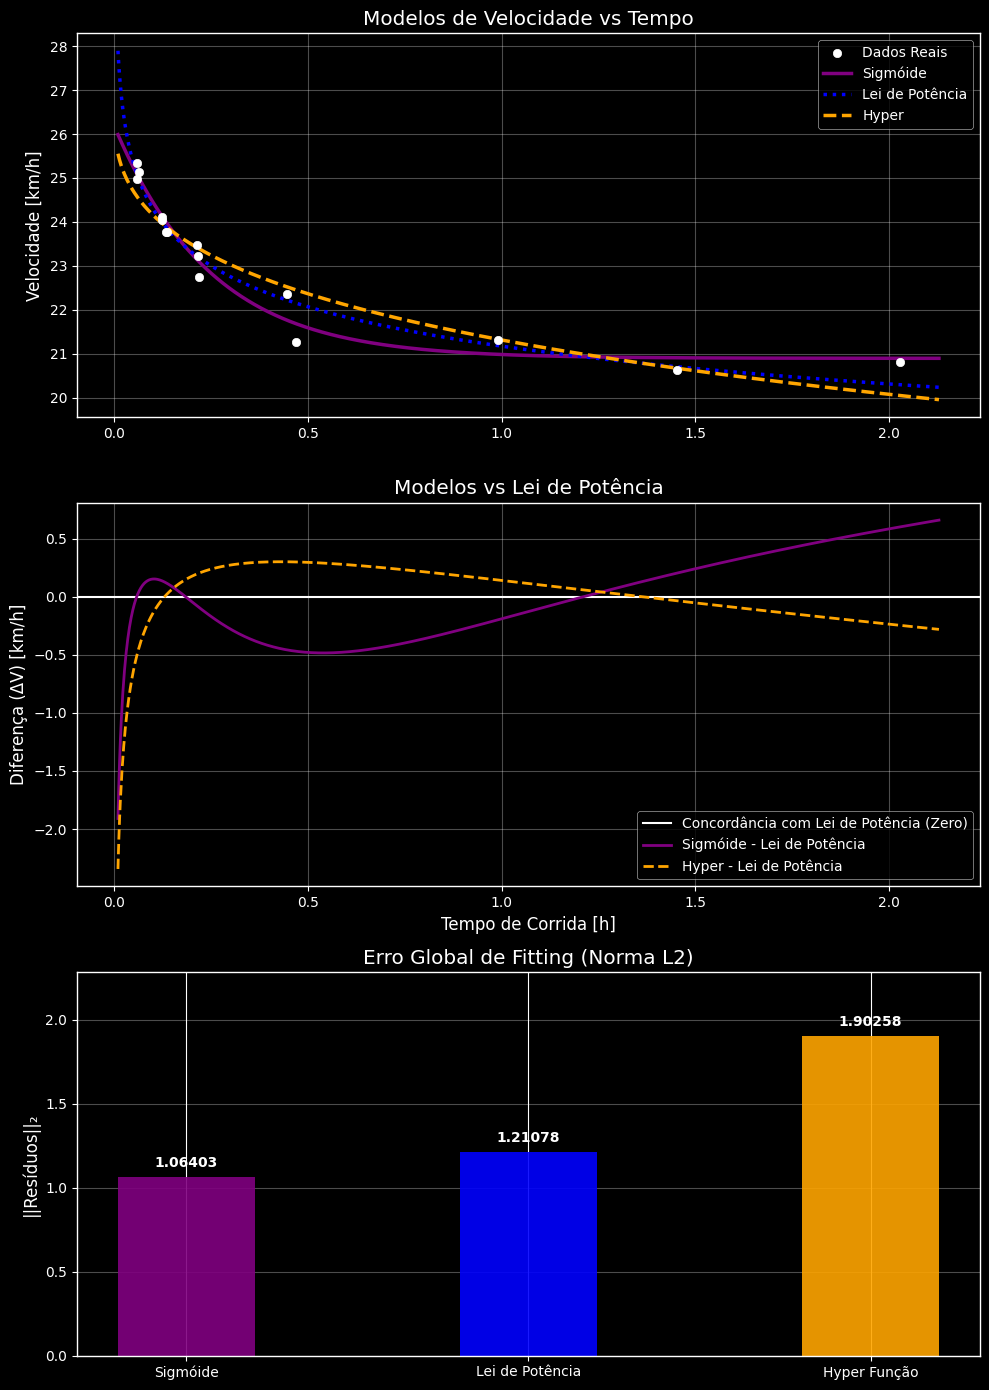

In [50]:
plt.style.use('dark_background')
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 14))

# Geração das predições contínuas para plotagem
T_plot = np.linspace(0.01, np.max(tempos) * 1.05, 1000) # Tempos próximos de zero até um pouco após o máximo
pred_sig = modelo_sigmoide(T_plot, *popt_sig) # operador * antes de uma lista atribui cada elemento da lista como uma variável na função
pred_pow = modelo_potencia(T_plot, *popt_pow)
pred_hyper = modelo_hyper(T_plot, *popt_hyper)

# --- Gráfico 1: Curvas de Velocidade ---
ax1.scatter(tempos, velocidades, color='white', label='Dados Reais', zorder=5)
ax1.plot(T_plot, pred_sig, color='purple', lw=2.5, label='Sigmóide')
ax1.plot(T_plot, pred_pow, color='blue', lw=2.5, ls=':', label='Lei de Potência')
ax1.plot(T_plot, pred_hyper, color='orange', lw=2.5, ls='--', label='Hyper')

ax1.set_ylabel('Velocidade [km/h]')
ax1.set_title('Modelos de Velocidade vs Tempo')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Gráfico 2: Divergência entre Modelos (Erro Relativo à Lei de Potência) ---
# Subtraímos a predição da Lei de Potência das outras predições para ver o afastamento
ax2.axhline(0, color='white', lw=1.5, label='Concordância com Lei de Potência (Zero)')
ax2.plot(T_plot, pred_sig - pred_pow, color='purple', lw=2.0, label='Sigmóide - Lei de Potência')
ax2.plot(T_plot, pred_hyper - pred_pow, color='orange', lw=2.0, ls='--', label='Hyper - Lei de Potência')

ax2.set_xlabel('Tempo de Corrida [h]')
ax2.set_ylabel('Diferença (ΔV) [km/h]')
ax2.set_title('Modelos vs Lei de Potência')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Gráfico 3: Erro Global (Norma L2 em Barras) ---
nomes = ['Sigmóide', 'Lei de Potência', 'Hyper Função']
normas = [norma_sig, norma_pow, norma_hyper]
cores = ['purple', 'blue', 'orange']

barras = ax3.bar(nomes, normas, color=cores, width=0.4, alpha=0.9)
ax3.set_ylabel('||Resíduos||₂')
ax3.set_title('Erro Global de Fitting (Norma L2)')
ax3.set_ylim(0, max(normas) * 1.2)
ax3.grid(axis='y', alpha=0.3)

for barra in barras:
    altura = barra.get_height()
    ax3.annotate(f'{altura:.5f}',
                 xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 5),
                 textcoords="offset points",
                 ha='center', va='bottom', 
                 color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [51]:
def prever_tempo_powerlaw(D_km, popt):
    # A equação analítica resolvida para T em horas: D = S * T^E -> T = (D/S)^(1/E)
    S_kmh, E = popt
    T_h = (D_km / S_kmh)**(1.0 / E)
    return T_h

def prever_tempo_numerico(modelo, popt, D_alvo_km, T_min_h=1e-8, T_max_h=100.0):
    def funcao_objetivo(T_h):
        # 1. O modelo recebe horas e cospe velocidade em km/h
        V_kmh = modelo(T_h, *popt)
        
        # 2. (Velocidade em km/h * Tempo em h) = Distância em km
        return (V_kmh * T_h) - D_alvo_km 
    
    # Encontra a raiz (o tempo em horas onde a diferença para a distância alvo é zero)
    return optimize.bisect(funcao_objetivo, T_min_h, T_max_h, xtol=1e-5)

def prever_velocidade_por_distancia(D_alvo_km):
    # Calcula os tempos previstos em horas
    T_pow_h = prever_tempo_powerlaw(D_alvo_km, popt_pow)
    T_sig_h = prever_tempo_numerico(modelo_sigmoide, popt_sig, D_alvo_km)
    T_hyper_h = prever_tempo_numerico(modelo_hyper, popt_hyper, D_alvo_km)
    
    # Velocidade Média = Distância / Tempo (ambos já em km e horas)
    V_pow_kmh = D_alvo_km / T_pow_h
    V_sig_kmh = D_alvo_km / T_sig_h
    V_hyper_kmh = D_alvo_km / T_hyper_h
    
    return V_pow_kmh, V_sig_kmh, V_hyper_kmh

# Exemplo de teste para a meia-maratona (21.0975 km)
print(prever_velocidade_por_distancia(0.0001))

(np.float64(46.251424322667305), 16.749115648570406, 16.749115648570406)


In [52]:
print(modelo_hyper(0,*popt_hyper))

26.61119999999995


### Gráficos Borges

#### Modelo de Potencia

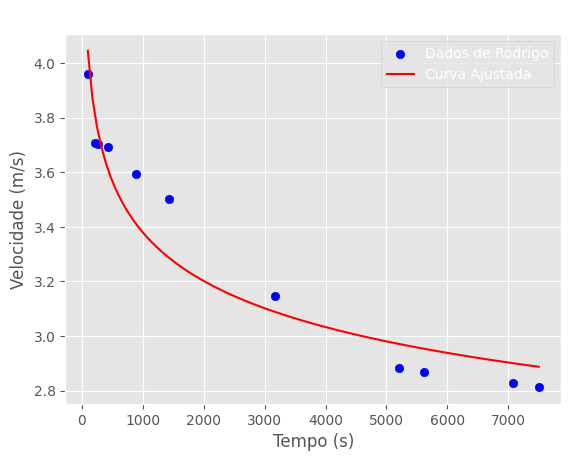

In [53]:
# Dados: distância em km e tempo em minutos
D_km = np.array([0.4, 0.8047, 1.0, 1.6093, 3.2187, 5.0, 10.0, 15.0, 16.0934, 20.0, 21.097])
T_min = np.array([1 + 41/60, 3 + 37/60, 4 + 30/60, 7 + 16/60, 14 + 56/60, 23 + 48/60, 52 + 57/60, 86 + 42/60, 93 + 30/60, 117 + 50/60, 124 + 57/60])

# Conversões
tempo_s = T_min * 60
D_m = D_km * 1000  # Convertendo quilômetros para metros

# Função de potência para o ajuste
def potencia_(t, S, e):
    return S * t**(e-1)

x = tempo_s
Y = D_m / tempo_s  # Agora a velocidade está em m/s

# Ajuste da curva usando a função em escala linear
popt, pcov = curve_fit(potencia_, x, Y)
S_fitted, e_fitted = popt

# Gerando pontos para a curva ajustada
t = np.linspace(min(x), max(x), 100)

# Plotagem
plt.style.use("ggplot")
plt.scatter(x, Y, label='Dados de Rodrigo', color='blue')
plt.plot(t, potencia_(t, S_fitted, e_fitted), label='Curva Ajustada', color='red')

# Atualização dos rótulos
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidade (m/s)')
plt.title('Ajuste da Curva Potência')
plt.legend()
plt.show()

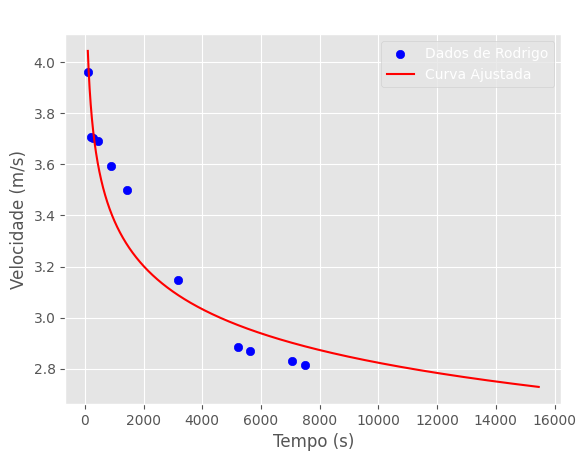

In [54]:
# Gerando pontos para a curva ajustada
t = np.linspace(min(x), (42195/S_fitted)**(1/e_fitted), 10000)

# Plotagem
plt.style.use("ggplot")
plt.scatter(x, Y, label='Dados de Rodrigo', color='blue')
plt.plot(t, potencia_(t, S_fitted, e_fitted), label='Curva Ajustada', color='red')

# Atualização dos rótulos
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidade (m/s)')
plt.title('Ajuste da Curva Potência')
plt.legend()
plt.show()

In [55]:
# Calculando o tempo projetado da maratona (em segundos)
t_maratona = (42195.0 / S_fitted) ** (1 / e_fitted)

# Convertendo para horas, minutos e segundos
horas = int(t_maratona // 3600)
minutos = int((t_maratona % 3600) // 60)
segundos = int(t_maratona % 60)

print(f"Estimativa para a Maratona: {horas} horas, {minutos} minutos e {segundos} segundos")


Estimativa para a Maratona: 4 horas, 17 minutos e 41 segundos


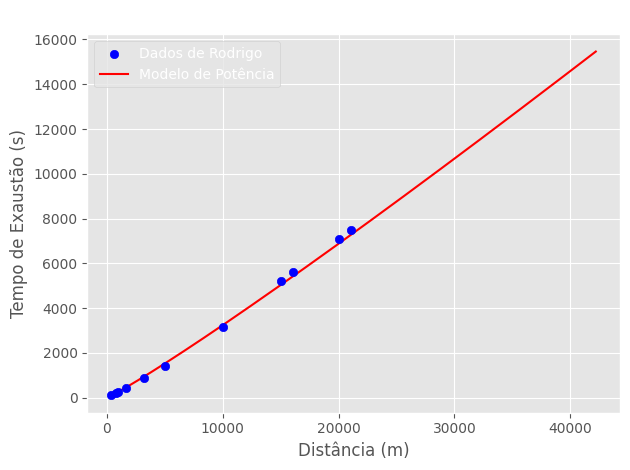

In [56]:
def tempo_exaustao(d, S, e):
    return (d / S)**(1 / e)

# Gerando distâncias para a curva contínua (desde o 1º ponto até a maratona)
d_curva = np.linspace(min(D_m), 42195.0, 1000)
# Calculando o tempo para cada uma dessas distâncias
t_curva = tempo_exaustao(d_curva, S_fitted, e_fitted)

# 4. PLOTAGEM
plt.style.use("ggplot")

# Dados originais de treino/prova
plt.scatter(D_m, tempo_s, label='Dados de Rodrigo', color='blue', zorder=3)

# Curva do modelo matemático
plt.plot(d_curva, t_curva, label='Modelo de Potência', color='red', zorder=2)

# Bônus: Destacando a projeção da Maratona com uma estrela amarela!
t_maratona = tempo_exaustao(42195.0, S_fitted, e_fitted)

# Configurando o visual
plt.xlabel('Distância (m)')
plt.ylabel('Tempo de Exaustão (s)')
plt.title('Tempo de Exaustão vs Distância')
plt.legend()
plt.tight_layout()
plt.show()

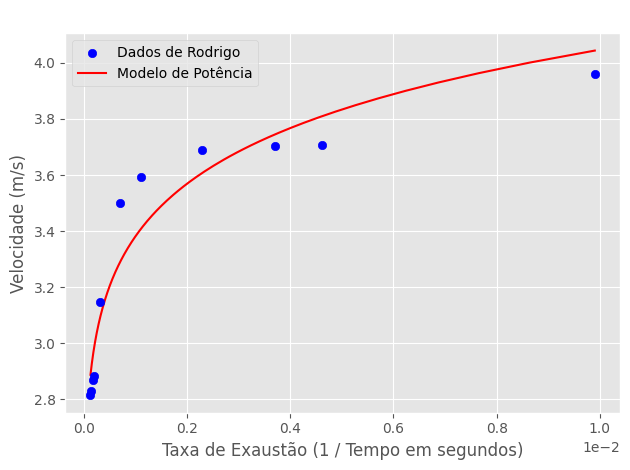

In [57]:
Y_vel = D_m / tempo_s
# 3. DADOS PARA O NOVO GRÁFICO (1/T)
inv_T_dados = 1 / tempo_s

# Gerando a linha do modelo ajustado
t_curva = np.linspace(min(tempo_s), max(tempo_s), 500)
vel_curva = potencia_(t_curva, S_fitted, e_fitted)
inv_T_curva = 1 / t_curva

# Para o matplotlib não desenhar a linha "voltando", precisamos ordenar os valores de X (1/T)
ordem = np.argsort(inv_T_curva)
inv_T_curva_ordenado = inv_T_curva[ordem]
vel_curva_ordenada = vel_curva[ordem]

# 4. PLOTAGEM
plt.style.use("ggplot")

# Scatter com os dados reais
plt.scatter(inv_T_dados, Y_vel, label='Dados de Rodrigo', color='blue', zorder=3)

# Linha da curva ajustada projetada no eixo 1/T
plt.plot(inv_T_curva_ordenado, vel_curva_ordenada, label='Modelo de Potência', color='red', zorder=2)

# Configurando o visual
plt.xlabel('Taxa de Exaustão (1 / Tempo em segundos)')
plt.ylabel('Velocidade (m/s)')
plt.title('Velocidade vs. 1/T (Análise de Velocidade Crítica)')

# Formatando o eixo X com notação científica para ficar mais limpo (já que os números são pequenos)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

plt.legend(labelcolor="black")
plt.tight_layout()
plt.show()

#### Outros modelos comparação

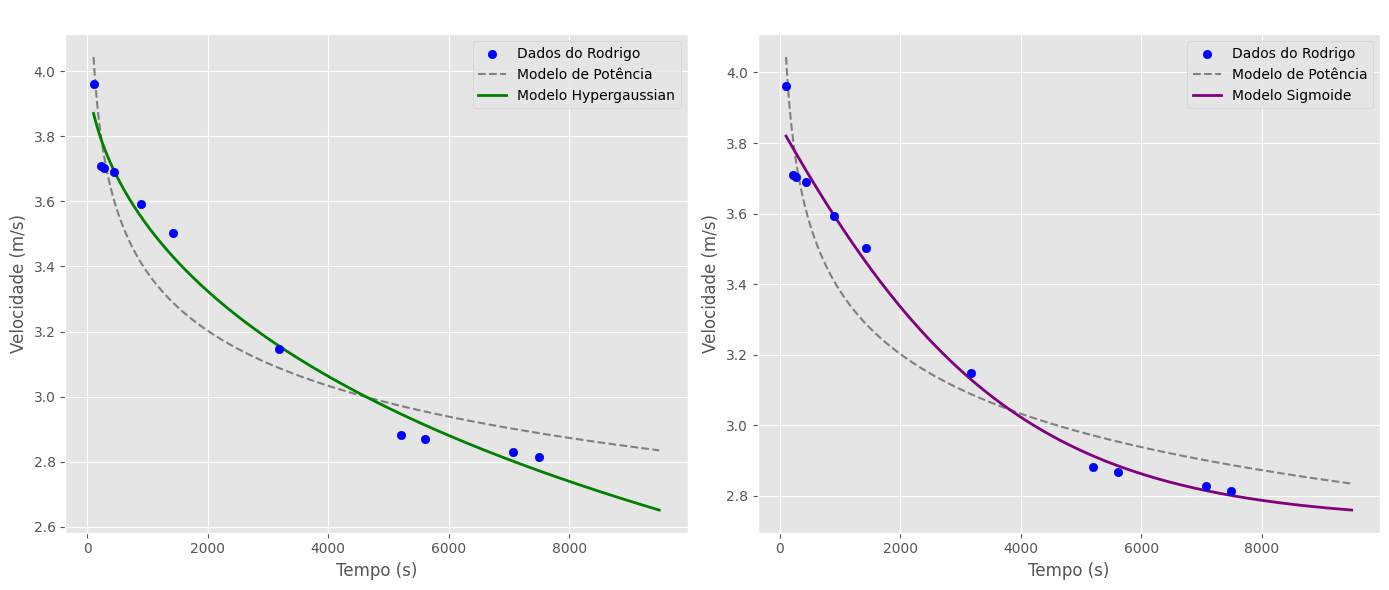

--- Parâmetros Ajustados ---
Hypergaussian: S = 4.01 m/s, e = 0.5830, g = 29861 s
Sigmoide: V_base = 2.73 m/s, A = 3.17 m/s, k = 0.00042, t0 = -1434 s


In [58]:
# 1. DADOS ORIGINAIS (Rodrigo)
D_km = np.array([0.4, 0.8047, 1.0, 1.6093, 3.2187, 5.0, 10.0, 15.0, 16.0934, 20.0, 21.097])
T_min = np.array([1 + 41/60, 3 + 37/60, 4 + 30/60, 7 + 16/60, 14 + 56/60, 23 + 48/60, 52 + 57/60, 86 + 42/60, 93 + 30/60, 117 + 50/60, 124 + 57/60])

tempo_s = T_min * 60
D_m = D_km * 1000
x = tempo_s
Y = D_m / tempo_s  # Velocidade em m/s

# 2. DEFINIÇÃO DOS MODELOS MATEMÁTICOS
def potencia_(t, S, e):
    return S * t**(e-1)

def hypergaussian(t, S, e, g):
    return S * (g**e) / (t**e + g**e)

def modelo_sigmoide(T, A, k, t0, V_base):
    return V_base + A / (1.0 + np.exp(k * (T - t0)))

# 3. AJUSTE DAS CURVAS (FIT)
# Chutes iniciais adaptados para m/s para garantir a convergência
popt_pot, _ = curve_fit(potencia_, x, Y, p0=[5.0, 0.9])
popt_hyp, _ = curve_fit(hypergaussian, x, Y, p0=[8.0, 0.5, 1000], maxfev=10000)

# Para a sigmoide: A (ganho de sprint) ~ 2.0 m/s, k (taxa) ~ 0.005, t0 (meio) ~ 500s, V_base (assíntota) ~ 2.8 m/s
popt_sig, _ = curve_fit(modelo_sigmoide, x, Y, p0=[2.0, 0.005, 500, 2.8], maxfev=10000)

# 4. PREPARAÇÃO PARA A PLOTAGEM
# Criando pontos de tempo suavizados para desenhar as linhas contínuas
t_plot = np.linspace(min(x), max(x) + 2000, 500) # Estiquei um pouco o eixo X para ver a assíntota

v_potencia = potencia_(t_plot, *popt_pot)
v_hyper = hypergaussian(t_plot, *popt_hyp)
v_sigmoide = modelo_sigmoide(t_plot, *popt_sig)

# 5. PLOTAGEM (Lado a Lado para Apresentação)
plt.style.use("ggplot")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6)) # 1 linha, 2 colunas

# --- GRÁFICO 1: Potência vs Seu Modelo (Hypergaussian) ---
ax1.scatter(x, Y, label='Dados do Rodrigo', color='blue', zorder=3)
ax1.plot(t_plot, v_potencia, label='Modelo de Potência', color='gray', linestyle='--')
ax1.plot(t_plot, v_hyper, label='Modelo Hypergaussian', color='green', linewidth=2)

ax1.set_xlabel('Tempo (s)')
ax1.set_ylabel('Velocidade (m/s)')
ax1.set_title('Potência vs. Hypergaussian')
ax1.legend(labelcolor="black")

# --- GRÁFICO 2: Potência vs Sigmoide (Amigo) ---
ax2.scatter(x, Y, label='Dados do Rodrigo', color='blue', zorder=3)
ax2.plot(t_plot, v_potencia, label='Modelo de Potência', color='gray', linestyle='--')
ax2.plot(t_plot, v_sigmoide, label='Modelo Sigmoide', color='purple', linewidth=2)

ax2.set_xlabel('Tempo (s)')
ax2.set_ylabel('Velocidade (m/s)')
ax2.set_title('Potência vs. Sigmoide')
ax2.legend(labelcolor="black")

# Ajuste de layout e exibição
plt.tight_layout()
plt.show()

# Imprimindo os parâmetros ajustados para você colocar nos slides
print("--- Parâmetros Ajustados ---")
print(f"Hypergaussian: S = {popt_hyp[0]:.2f} m/s, e = {popt_hyp[1]:.4f}, g = {popt_hyp[2]:.0f} s")
print(f"Sigmoide: V_base = {popt_sig[3]:.2f} m/s, A = {popt_sig[0]:.2f} m/s, k = {popt_sig[1]:.5f}, t0 = {popt_sig[2]:.0f} s")

In [59]:
# Calculando as velocidades teóricas no instante t = 0
v_hyper_zero = hypergaussian(0, *popt_hyp)
v_sigmoide_zero = modelo_sigmoide(0, *popt_sig)

# Exibindo os resultados no console
print("\n--- Velocidade Teórica Inicial (t = 0 s) ---")
print(f"Seu Modelo (Hypergaussian): {v_hyper_zero:.2f} m/s")
print(f"Modelo do Amigo (Sigmoide): {v_sigmoide_zero:.2f} m/s")


--- Velocidade Teórica Inicial (t = 0 s) ---
Seu Modelo (Hypergaussian): 4.01 m/s
Modelo do Amigo (Sigmoide): 3.85 m/s


In [60]:
from scipy.optimize import bisect

# 1. As funções de velocidade originais
def hypergaussian(t, S, e, g):
    return S * (g**e) / (t**e + g**e)

def modelo_sigmoide(T, A, k, t0, V_base):
    return V_base + A / (1.0 + np.exp(k * (T - t0)))

# 2. Criando as funções de "Zero" (f(t) = 0)
def zero_hypergaussian(t, D_alvo, S, e, g):
    velocidade = hypergaussian(t, S, e, g)
    distancia_calculada = velocidade * t
    return distancia_calculada - D_alvo

def zero_sigmoide(t, D_alvo, A, k, t0, V_base):
    velocidade = modelo_sigmoide(t, A, k, t0, V_base)
    distancia_calculada = velocidade * t
    return distancia_calculada - D_alvo

# --- APLICANDO A BISSEÇÃO ---
# Vamos supor que você quer o tempo de uma Maratona (42195 metros)
distancia_alvo = 42195.0

# Precisamos definir um intervalo [a, b] onde a raiz com certeza está.
# a = 10 segundos (muito rápido), b = 50000 segundos (~14 horas, bem lento)
limite_inferior = 10
limite_superior = 50000

# Executando a bisseção (supondo que popt_hyp e popt_sig são os parâmetros que você ajustou antes)
tempo_seu_modelo = bisect(zero_hypergaussian, limite_inferior, limite_superior, args=(distancia_alvo, *popt_hyp))
tempo_amigo = bisect(zero_sigmoide, limite_inferior, limite_superior, args=(distancia_alvo, *popt_sig))
m_mod, s_mod = divmod(int(tempo_seu_modelo), 60)
h_mod, m_mod = divmod(m_mod, 60)

# Cálculos para o modelo do amigo
m_amigo, s_amigo = divmod(int(tempo_amigo), 60)
h_amigo, m_amigo = divmod(m_amigo, 60)


# o borges jogou tudo no chat gpt
# eu sou o amigo

print("Tempo exato projetado para a Maratona:")
print(f"Hypergaussian: {h_mod} horas, {m_mod} minutos e {s_mod} segundos")
print(f"Sigmoide: {h_amigo} horas, {m_amigo} minutos e {s_amigo} segundos")

Tempo exato projetado para a Maratona:
Hypergaussian: 5 horas, 7 minutos e 50 segundos
Sigmoide: 4 horas, 17 minutos e 33 segundos


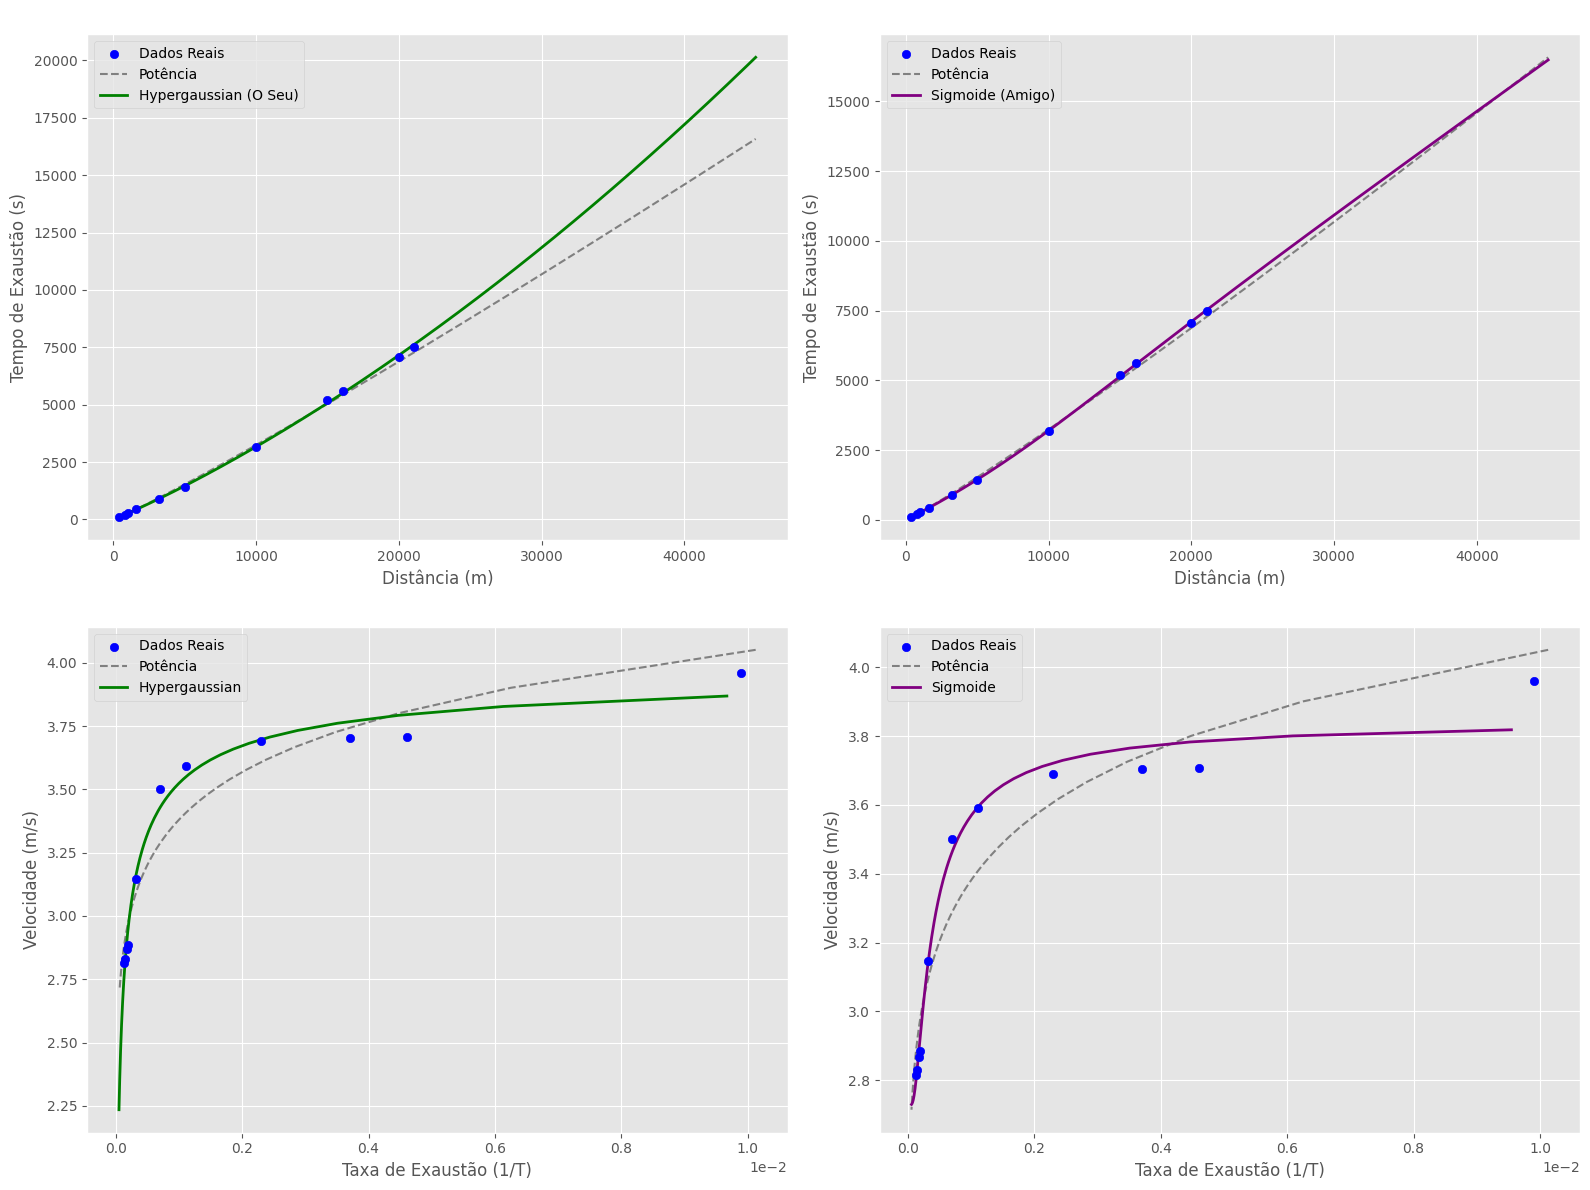

In [61]:
import numpy as np
from scipy.optimize import curve_fit, bisect
import matplotlib.pyplot as plt

# 1. DADOS ORIGINAIS
D_km = np.array([0.4, 0.8047, 1.0, 1.6093, 3.2187, 5.0, 10.0, 15.0, 16.0934, 20.0, 21.097])
T_min = np.array([1 + 41/60, 3 + 37/60, 4 + 30/60, 7 + 16/60, 14 + 56/60, 23 + 48/60, 52 + 57/60, 86 + 42/60, 93 + 30/60, 117 + 50/60, 124 + 57/60])

tempo_s = T_min * 60
D_m = D_km * 1000
Y_vel = D_m / tempo_s  # Velocidade em m/s

# 2. DEFINIÇÃO DOS MODELOS
def potencia_(t, S, e):
    return S * t**(e-1)

def hypergaussian(t, S, e, g):
    return S * (g**e) / (t**e + g**e)

def modelo_sigmoide(T, A, k, t0, V_base):
    return V_base + A / (1.0 + np.exp(k * (T - t0)))

# 3. AJUSTE DAS CURVAS (FIT)
popt_pot, _ = curve_fit(potencia_, tempo_s, Y_vel, p0=[5.0, 0.9])
popt_hyp, _ = curve_fit(hypergaussian, tempo_s, Y_vel, p0=[8.0, 0.5, 1000], maxfev=10000)
popt_sig, _ = curve_fit(modelo_sigmoide, tempo_s, Y_vel, p0=[2.0, 0.005, 500, 2.8], maxfev=10000)

# 4. FUNÇÕES DE ZERO PARA A BISSEÇÃO (f(t) = 0)
def zero_hypergaussian(t, D_alvo, S, e, g):
    return hypergaussian(t, S, e, g) * t - D_alvo

def zero_sigmoide(t, D_alvo, A, k, t0, V_base):
    return modelo_sigmoide(t, A, k, t0, V_base) * t - D_alvo

# 5. GERANDO DADOS VIA BISSEÇÃO
D_plot = np.linspace(min(D_m), 45000, 200)

T_pot_plot = []
T_hyp_plot = []
T_sig_plot = []

limite_inf = 1.0
limite_sup = 100000.0

for d in D_plot:
    # Potência (analítico)
    t_pot = (d / popt_pot[0]) ** (1 / popt_pot[1])
    T_pot_plot.append(t_pot)

    # Seu Modelo (Bisseção)
    t_hyp = bisect(zero_hypergaussian, limite_inf, limite_sup, args=(d, *popt_hyp))
    T_hyp_plot.append(t_hyp)

    # Modelo Amigo (Bisseção)
    t_sig = bisect(zero_sigmoide, limite_inf, limite_sup, args=(d, *popt_sig))
    T_sig_plot.append(t_sig)

T_pot_plot = np.array(T_pot_plot)
T_hyp_plot = np.array(T_hyp_plot)
T_sig_plot = np.array(T_sig_plot)

# 6. PLOTAGEM DOS 4 GRÁFICOS
plt.style.use("ggplot")
# Criando uma figura grande com 2 linhas e 2 colunas
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# --- LINHA 1, COLUNA 1: D vs T (Seu Modelo) ---
axs[0, 0].scatter(D_m, tempo_s, label='Dados Reais', color='blue', zorder=5)
axs[0, 0].plot(D_plot, T_pot_plot, label='Potência', color='gray', linestyle='--')
axs[0, 0].plot(D_plot, T_hyp_plot, label='Hypergaussian (O Seu)', color='green', linewidth=2)
axs[0, 0].set_xlabel('Distância (m)')
axs[0, 0].set_ylabel('Tempo de Exaustão (s)')
axs[0, 0].set_title('Distância vs Tempo: Potência x Hypergaussian')
axs[0, 0].legend(labelcolor="black")

# --- LINHA 1, COLUNA 2: D vs T (Modelo do Amigo) ---
axs[0, 1].scatter(D_m, tempo_s, label='Dados Reais', color='blue', zorder=5)
axs[0, 1].plot(D_plot, T_pot_plot, label='Potência', color='gray', linestyle='--')
axs[0, 1].plot(D_plot, T_sig_plot, label='Sigmoide (Amigo)', color='purple', linewidth=2)
axs[0, 1].set_xlabel('Distância (m)')
axs[0, 1].set_ylabel('Tempo de Exaustão (s)')
axs[0, 1].set_title('Distância vs Tempo: Potência x Sigmoide')
axs[0, 1].legend(labelcolor="black")

# --- LINHA 2, COLUNA 1: Vel vs 1/T (Seu Modelo) ---
axs[1, 0].scatter(1/tempo_s, Y_vel, label='Dados Reais', color='blue', zorder=5)
axs[1, 0].plot(1/T_pot_plot, D_plot/T_pot_plot, label='Potência', color='gray', linestyle='--')
axs[1, 0].plot(1/T_hyp_plot, D_plot/T_hyp_plot, label='Hypergaussian', color='green', linewidth=2)
axs[1, 0].set_xlabel('Taxa de Exaustão (1/T)')
axs[1, 0].set_ylabel('Velocidade (m/s)')
axs[1, 0].set_title('Análise Assintótica: Potência x Hypergaussian')
axs[1, 0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
axs[1, 0].legend(labelcolor="black")

# --- LINHA 2, COLUNA 2: Vel vs 1/T (Modelo do Amigo) ---
axs[1, 1].scatter(1/tempo_s, Y_vel, label='Dados Reais', color='blue', zorder=5)
axs[1, 1].plot(1/T_pot_plot, D_plot/T_pot_plot, label='Potência', color='gray', linestyle='--')
axs[1, 1].plot(1/T_sig_plot, D_plot/T_sig_plot, label='Sigmoide', color='purple', linewidth=2)
axs[1, 1].set_xlabel('Taxa de Exaustão (1/T)')
axs[1, 1].set_ylabel('Velocidade (m/s)')
axs[1, 1].set_title('Análise Assintótica: Potência x Sigmoide')
axs[1, 1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
axs[1, 1].legend(labelcolor="black")

# Ajuste automático dos espaços para não encavalar os textos
plt.tight_layout()
plt.show()

In [62]:
from scipy.optimize import bisect

def get_velocity_by_distance(meters, modelo, popt, limite_inf=1e-8, limite_sup=1e8):
    """
    Calcula o tempo, a velocidade média e a velocidade instantânea para uma distância alvo.
    
    Parâmetros:
    - meters: A distância alvo em metros
    - modelo: A função matemática do modelo
    - popt: Os parâmetros fittados do modelo
    """
    
    # 1. Função objetivo
    def objetivo_distancia(t):
        velocidade_media = modelo(t, *popt)
        distancia_calculada = velocidade_media * t
        return distancia_calculada - meters
    
    # 2. Encontra o tempo exato (em segundos) usando bisseção
    tempo_alvo_s = bisect(objetivo_distancia, limite_inf, limite_sup, xtol=1e-5)
    
    # 3. Calcula a Velocidade Média (m/s e km/h)
    v_media_ms = meters / tempo_alvo_s
    v_media_kmh = v_media_ms * 3.6
    
    # 4. Calcula a Velocidade Instantânea usando derivada numérica (D(t + dt) - D(t)) / dt
    dt = 0.001 # Um passo à frente de 1 décimo de segundo
    distancia_frente = modelo(tempo_alvo_s + dt, *popt) * (tempo_alvo_s + dt)
    v_inst_ms = (distancia_frente - meters) / dt
    v_inst_kmh = v_inst_ms * 3.6
    
    # Converte o tempo para horas, minutos e segundos para facilitar a leitura
    m, s = divmod(int(tempo_alvo_s), 60)
    h, m = divmod(m, 60)
    tempo_formatado = f"{h}h {m}m {s}s"
    
    return {
        "distancia_m": meters,
        "tempo_s": tempo_alvo_s,
        "tempo_formatado": tempo_formatado,
        "velocidade_media_ms": v_media_ms,
        "velocidade_media_kmh": v_media_kmh,
        "velocidade_instantanea_ms": v_inst_ms,
        "velocidade_instantanea_kmh": v_inst_kmh
    }


In [63]:
# Testando para a Hypergaussiana
resultado = get_velocity_by_distance(0.001, hypergaussian, popt_hyp)
print(resultado)
# print(f"--- Previsão para {resultado['distancia_m']} metros ---")
# print(f"Tempo estimado: {resultado['tempo_formatado']}")
# print(f"Velocidade Média Global: {resultado['velocidade_media_kmh']:.2f} km/h (Pace total)")
# print(f"Velocidade Instantânea na linha de chegada: {resultado['velocidade_instantanea_kmh']:.2f} km/h (Pace final)")

{'distancia_m': 0.001, 'tempo_s': 0.0002444367011014744, 'tempo_formatado': '0h 0m 0s', 'velocidade_media_ms': 4.091038684018503, 'velocidade_media_kmh': 14.727739262466612, 'velocidade_instantanea_ms': np.float64(3.9910804813504344), 'velocidade_instantanea_kmh': np.float64(14.367889732861563)}


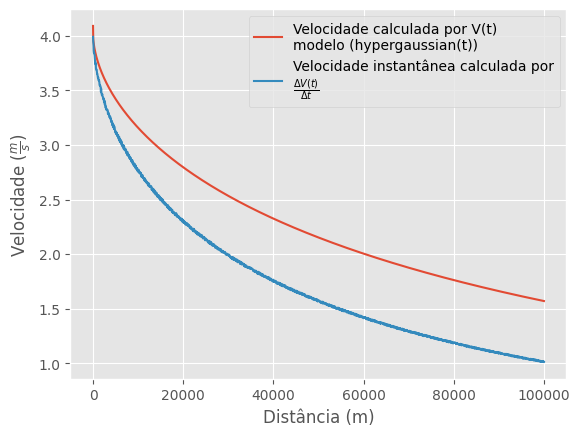

In [64]:
model = "hypergaussian(t)"

Xs = np.linspace(0.001,100000,num=2000)
Ys = np.array([
    get_velocity_by_distance(x, hypergaussian, popt_hyp)['velocidade_media_ms']
    for x in Xs
])
Ys1 = np.array([
    get_velocity_by_distance(x, hypergaussian, popt_hyp)['velocidade_instantanea_ms']
    for x in Xs
])

plt.plot(
    Xs,
    Ys,
    label=f"Velocidade calculada por V(t)\nmodelo ({model})"
)

plt.plot(
    Xs,
    Ys1,
    label=r"Velocidade instantânea calculada por"
          "\n"
          r"$\frac{\Delta V(t)}{\Delta t}$"
)

plt.legend(
    labelcolor="black",
    loc='upper right',
    bbox_to_anchor=(1., 1)
)

plt.xlabel("Distância (m)")
plt.ylabel(r"Velocidade ($\frac{m}{s}$)")
plt.show()